2026-05-19 21:16:37.690071: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 21:16:37.701867: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779196597.715127   24161 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779196597.719116   24161 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-19 21:16:37.734052: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` 

449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` 

388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/ustc15/anaconda3/envs/nsac/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


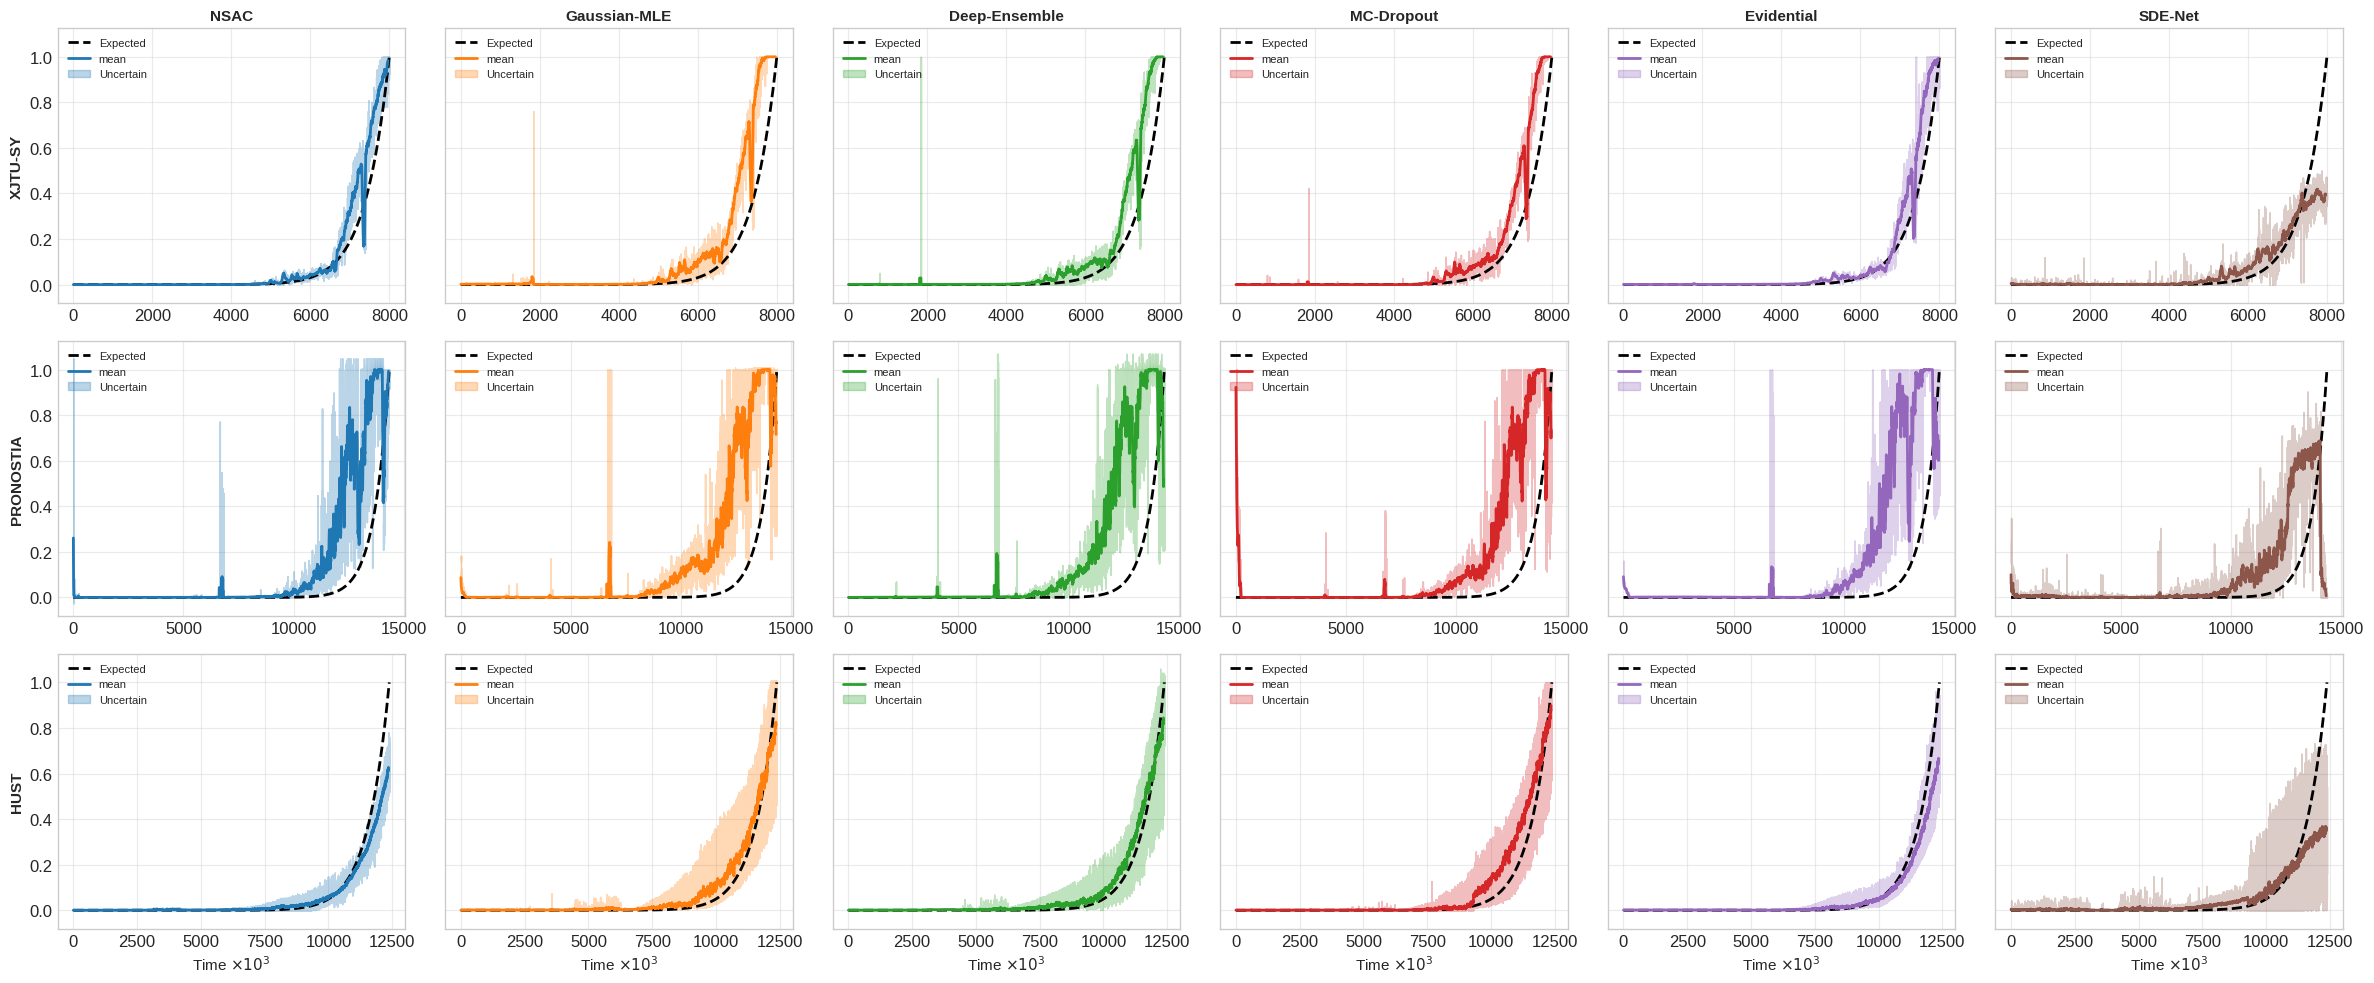

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras._tf_keras.keras.models import Model
from keras._tf_keras.keras.layers import Input, Dense, Reshape, Conv1D
from sklearn.preprocessing import StandardScaler
from utils.preprocess import process_features
from neuronal_attention_circuit import NAC

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from metrics import compute_crps, compute_ece

from ouwrap import OUWrap
from losses import NSACLoss, NLL
from neuronal_attention_circuit import NAC
from neuronal_stochastic_attention_circuit import NSAC

from baselines import GMLE, DeepEnsemble, MC_dropout, Evidential, SDE_Net
from evidential_deep_learning.layers import DenseNormalGamma
from evidential_deep_learning.losses import EvidentialRegression

from utils.preprocess import process_features


# Directories
plot_dir = 'plots'
os.makedirs(plot_dir, exist_ok=True)

MODEL_NAME = 'rul'
WEIGHTS_DIR = 'model_weights'

# Moving average
def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


# Model Builders
def _build_nsac():
    def model_fn(input_shape=(16,)):
        inputs = tf.keras.layers.Input(input_shape)
        x = tf.keras.layers.Reshape((1, input_shape[0]))(inputs)
        mean, log_std = OUWrap(
            NAC(d_model=100, num_heads=20, topk=8, sparsity=0.7),
            output_dim=1,
            activation='relu',
            return_sequences=False
        )(x)
        return tf.keras.Model(inputs=inputs, outputs=[mean, log_std])
    model = NSAC(stochastic_model_fn=model_fn(), ood_std=5.0)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4),loss=NSACLoss())
    return model

def _build_mle():
    def model_fn(input_shape=(16,)):
        inputs = tf.keras.layers.Input(input_shape)
        x = tf.keras.layers.Reshape((1, input_shape[0]))(inputs)
        x = NAC(
            d_model=100, num_heads=20, topk=8, mode='exact',
            sparsity=0.8, activation='relu', return_sequences=False)(x)
        mean = tf.keras.layers.Dense(1, activation='linear')(x)
        log_std = tf.keras.layers.Dense(1, activation='linear')(x)
        return tf.keras.Model(inputs=inputs, outputs=[mean, log_std])
    model = GMLE(model_fn())
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=NLL())
    return model

def _build_deep_ensemble():
    def model_fn(input_shape=(16,)):
        inp = tf.keras.layers.Input(input_shape)
        x = tf.keras.layers.Reshape((1, input_shape[0]))(inp)
        x = NAC(
            d_model=100, num_heads=20, topk=8, mode='exact',
            sparsity=0.8, activation='relu', return_sequences=False)(x)
        mu = tf.keras.layers.Dense(1)(x)
        log_std = tf.keras.layers.Dense(1)(x)
        return tf.keras.Model(inp, [mu, log_std])
    model = DeepEnsemble(model_fn=model_fn())
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=NLL())
    return model

def _build_mc_dropout():
    def model_fn(input_shape=(16,)):
        inp = tf.keras.layers.Input(input_shape)
        x = tf.keras.layers.Reshape((1, input_shape[0]))(inp)
        x = NAC(
            d_model=100, num_heads=20, topk=8, mode='exact',
            sparsity=0.8, activation='relu', return_sequences=False)(x)
        mu = tf.keras.layers.Dense(1)(x)
        log_std = tf.keras.layers.Dense(1)(x)
        return tf.keras.Model(inp, [mu, log_std])
    model = MC_dropout(model_fn=model_fn())
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4), loss=NLL())
    return model


def _build_evidential():
    def model_fn(input_shape=(16,)):
        inputs = tf.keras.layers.Input(input_shape)
        x = tf.keras.layers.Reshape((1, input_shape[0]))(inputs)
        x = NAC(
            d_model=100, num_heads=20, topk=8, mode='exact',
            sparsity=0.8, activation='relu', return_sequences=False)(x)
        outputs = DenseNormalGamma(1)(x)
        return tf.keras.Model(inputs, outputs)
    model = Evidential(model_fn=model_fn(), lambda_reg=0.5)
    model.compile(optimizer=tf.keras.optimizers.AdamW(1e-3), loss=EvidentialRegression)
    return model

def _build_sde_net():
    model = SDE_Net(input_dim=X.shape[1], output_dim=1, hidden_dim=64, layer_depth=6)
    model.compile(
        optimizer_drift = tf.keras.optimizers.AdamW(0.0001),
        optimizer_fc = tf.keras.optimizers.AdamW(0.0001),
        optimizer_dsl = tf.keras.optimizers.AdamW(0.0001),
        optimizer_diffusion = tf.keras.optimizers.AdamW(0.001),
        loss = NLL()
    )
    return model

# Model List
model_list = [
    "NSAC",
    "Gaussian-MLE",
    "Deep-Ensemble",
    "MC-Dropout",
    "Evidential",
    "SDE-Net",
]



# Bearings dictionary
bearings = {
    "tf_features_xjtu": "Bearing1_1_features_with_labels.csv",
    "tf_features_pronostia": "Bearing1_1_features.csv",
    "tf_features_hust": "Bearing1_features.csv",
}

bearing_titles = {
    "tf_features_xjtu": "XJTU-SY",
    "tf_features_pronostia": "PRONOSTIA",
    "tf_features_hust": "HUST"
}

import matplotlib.cm as cm

color_map = {
    name: cm.tab10(i) for i, name in enumerate(model_list)
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.0,
    "lines.markersize": 3,
})

# Uncertainty scaling factors for visualization
scales = {"NSAC": 0.05,  
          "Gaussian-MLE": 0.01,  
          "Deep-Ensemble": 0.07,  
          "MC-Dropout": 0.001,  
          "Evidential": 0.0001,  
          "SDE-Net": 0.0007,
          }


fig, axes = plt.subplots(3, len(model_list), figsize=(4 * len(model_list), 10), sharey=True)

for row, (bearing_folder, bearing_file) in enumerate(bearings.items()):

    # data loading and preprocessing
    df = pd.read_csv(os.path.join(os.getcwd(), bearing_folder, bearing_file))
    xh = process_features(np.array(df['Horizontal'].apply(eval).tolist()))
    xv = process_features(np.array(df['Vertical'].apply(eval).tolist()))
    vibration_features = np.concatenate((xh, xv), axis=-1)
    t_data = df['Time'].values.reshape(-1, 1)
    if "Temperature" in df.columns:
        T_data = (df['Temperature'].values + 273.15).reshape(-1, 1)
    else:
        T_data = np.full((len(df), 1), 298.15)
    X = np.concatenate([vibration_features, t_data, T_data], axis=1)
    X = StandardScaler().fit_transform(X)
    y_true = df['Degradation'].values if "Degradation" in df.columns else np.linspace(0, 1, len(df))

# Loop through models
    for col, name in enumerate(model_list):
        ax = axes[row, col]

        # Expected curve
        ax.plot(y_true, '--', color='black', linewidth=2,label='Expected')

        # build model
        if name == "NSAC":
            model = _build_nsac()
        elif name == "Gaussian-MLE":
            model = _build_mle()
        elif name == "Deep-Ensemble":
            model = _build_deep_ensemble()
        elif name == "MC-Dropout":
            model = _build_mc_dropout()
        elif name == "Evidential":
            model = _build_evidential()
        elif name == "SDE-Net":
            model = _build_sde_net()

        model.load_weights(f'{WEIGHTS_DIR}/{name}_{MODEL_NAME}_weights_2.keras')

        mu, std = model.predict(X)

        mu = mu[0].squeeze() if isinstance(mu, (list, tuple)) else mu.squeeze()
        std = std[0].squeeze() if isinstance(std, (list, tuple)) else std.squeeze()
        mu = np.clip(mu, 0, 1)
        std = np.clip(std, 0, 1)



        ax.plot(moving_average(mu, window_size=35),color=color_map[name], linewidth=2, label='mean')
        ax.fill_between(
            np.arange(len(mu)),
            mu - scales[name]*std,
            mu + scales[name]*std,
            color=color_map[name],
            alpha=0.3,
            label=f'Uncertain'
        )

        # titles / labels
        if row == 0:
            ax.set_title(name, fontsize=11, fontweight='bold')

        if col == 0:
            ax.set_ylabel(bearing_titles[bearing_folder], fontsize=11, fontweight='bold')

        if row == 2:
            ax.set_xlabel(r'Time $\times 10^3$')

        ax.grid(alpha=0.4)

        ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f'{MODEL_NAME}_uncertainty_comparison.png'), dpi=600)
plt.show()